<a href="https://colab.research.google.com/github/yashwini321/yashwini/blob/main/sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Sample Overview
   Store_Size_SQFT  Promo_Discount_Pct  Foot_Traffic  Is_Weekend  \
0            20795           39.389494          1062           1   
1             5860           30.186077          1927           0   
2            10390            5.713365          2983           0   
3            16964           20.725229          1713           0   
4            16284           43.175907          1740           1   

   Competitor_Distance_KM         Sales  
0               14.100496  28429.503054  
1                1.734001  26056.258931  
2                6.091165  40142.678113  
3                1.530006  30372.087979  
4                3.556500  36918.649572   

Training Random Forest Regressor Model...

 Model Evaluation Summary
Root Mean Squared Error (RMSE): ₹1885.19
R-squared Score (Accuracy): 0.9664 (96.6%)

 Feature Drivers Impacting Sales Predictions
Foot_Traffic              0.888886
Store_Size_SQFT           0.055668
Promo_Discount_Pct        0.045728
Competito

/tmp/ipykernel_2720/2157286914.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


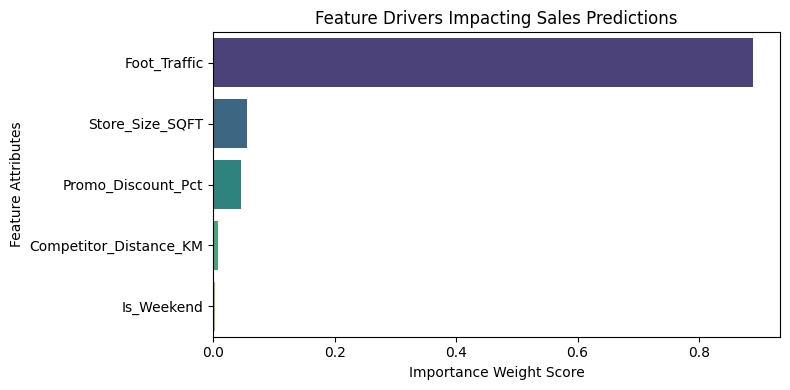

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
np.random.seed(42)
n_samples = 1000
data = {
    'Store_Size_SQFT': np.random.randint(5000, 25000, n_samples),
    'Promo_Discount_Pct': np.random.uniform(0, 50, n_samples),
    'Foot_Traffic': np.random.randint(100, 3000, n_samples),
    'Is_Weekend': np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3]),
    'Competitor_Distance_KM': np.random.uniform(0.5, 15, n_samples),
}

df = pd.DataFrame(data)
df['Sales'] = (
    (df['Store_Size_SQFT'] * 0.4) +
    (df['Promo_Discount_Pct'] * 150) +
    (df['Foot_Traffic'] * 12) +
    (df['Is_Weekend'] * 2000) -
    (df['Competitor_Distance_KM'] * 100) +
    np.random.normal(0, 1500, n_samples)
)
print("Dataset Sample Overview")
print(df.head(), "\n")
x = df.drop('Sales', axis=1)
y = df['Sales']
xtrain, xtest, ytrain, ytest = train_test_split(x, y,test_size=0.33, random_state=42)
print("Training Random Forest Regressor Model...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(xtrain, ytrain)
y_pred = model.predict(xtest)
rmse = np.sqrt(mean_squared_error(ytest, y_pred))
r2 = r2_score(ytest, y_pred)
print("\n Model Evaluation Summary")
print(f"Root Mean Squared Error (RMSE): ₹{rmse:.2f}")
print(f"R-squared Score (Accuracy): {r2:.4f} ({r2*100:.1f}%)")
feature_importances = pd.Series(model.feature_importances_ ,index=x.columns).sort_values(ascending=False)
print("\n Feature Drivers Impacting Sales Predictions")
print(feature_importances)
plt.figure(figsize=(8, 4))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Drivers Impacting Sales Predictions')
plt.xlabel('Importance Weight Score')
plt.ylabel('Feature Attributes')
plt.tight_layout()
plt.show()